“By transforming raw Aadhaar activity data into behavioral and structural indicators, we identify not only where demand exists, but how the system behaves under that demand. This enables UIDAI to differentiate between districts that require outreach, those that require capacity reinforcement, and those ready for process optimization.”

### Digital Maturity Map (District Level)

In [15]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

In [16]:
digital_maturity_df = pd.read_csv("data/digital_maturity_df.csv")

In [17]:
district_gdf = gpd.read_file("data/india_district.geojson")

In [18]:
digital_maturity_df.head()

,state,district,mean_update_to_enrolment_ratio,mean_update_dependency,update_to_enrolment_ratio_volatility,dependency_volatility,pct_active_months,activity_growth_slope,maturity_cluster,mean_monthly_activity
0,ANDAMAN & NICOBAR ISLANDS,ANDAMANS,106.583631,0.879568,97.416098,0.309773,0.9,42.703030,0,284.0
1,ANDAMAN & NICOBAR ISLANDS,NICOBARS,0.550000,0.163333,1.257201,0.285644,0.3,0.260606,1,0.7
2,ANDAMAN & NICOBAR ISLANDS,SOUTH ANDAMAN,6.728472,0.376071,9.163387,0.485612,0.4,26.375758,1,71.0
3,ANDAMAN AND NICOBAR ISLANDS,NICOBAR,149.532449,0.873744,207.028878,0.308890,0.9,-9.145455,0,267.3
4,ANDAMAN AND NICOBAR ISLANDS,NORTH AND MIDDLE ANDAMAN,501.677162,0.884397,563.351927,0.311274,0.9,-12.933333,0,852.4


In [19]:
cluster_name_map = {
    0: "High Activity - Unstable / Transitioning",
    1: "Emerging Growth",
    2: "Dormant / Low Coverage",
    3: "High Stress / Legacy Heavy"
}

digital_maturity_df["maturity_label"] = (
    digital_maturity_df["maturity_cluster"]
    .map(cluster_name_map)
)


In [20]:
digital_maturity_df.head()

,state,district,mean_update_to_enrolment_ratio,mean_update_dependency,update_to_enrolment_ratio_volatility,dependency_volatility,pct_active_months,activity_growth_slope,maturity_cluster,mean_monthly_activity,maturity_label
0,ANDAMAN & NICOBAR ISLANDS,ANDAMANS,106.583631,0.879568,97.416098,0.309773,0.9,42.703030,0,284.0,High Activity - Unstable / Transitioning
1,ANDAMAN & NICOBAR ISLANDS,NICOBARS,0.550000,0.163333,1.257201,0.285644,0.3,0.260606,1,0.7,Emerging Growth
2,ANDAMAN & NICOBAR ISLANDS,SOUTH ANDAMAN,6.728472,0.376071,9.163387,0.485612,0.4,26.375758,1,71.0,Emerging Growth
3,ANDAMAN AND NICOBAR ISLANDS,NICOBAR,149.532449,0.873744,207.028878,0.308890,0.9,-9.145455,0,267.3,High Activity - Unstable / Transitioning
4,ANDAMAN AND NICOBAR ISLANDS,NORTH AND MIDDLE ANDAMAN,501.677162,0.884397,563.351927,0.311274,0.9,-12.933333,0,852.4,High Activity - Unstable / Transitioning


In [21]:
# Standardize district_gdf
district_gdf["state"] = (
    district_gdf["NAME_1"]
    .str.upper()
    .str.strip()
)

district_gdf["district"] = (
    district_gdf["NAME_2"]
    .str.upper()
    .str.strip()
)

# Standardize digital_maturity_df
digital_maturity_df["state"] = (
    digital_maturity_df["state"]
    .str.upper()
    .str.strip()
)

digital_maturity_df["district"] = (
    digital_maturity_df["district"]
    .str.upper()
    .str.strip()
)


In [22]:
district_gdf.head(1)

,ID_0,ISO,NAME_0,ID_1,NAME_1,ID_2,NAME_2,NL_NAME_2,VARNAME_2,TYPE_2,ENGTYPE_2,geometry,state,district
0,105,IND,India,1,Andaman and Nicobar,1,Andaman Islands,None,None,District,District,"MULTIPOLYGON (((92.51583 10.89764, 92.51611 10...",ANDAMAN AND NICOBAR,ANDAMAN ISLANDS


In [23]:
map_df = district_gdf.merge(
    digital_maturity_df[
        ["state", "district", "maturity_label"]
    ],
    on=["state", "district"],
    how="left"
)


In [24]:
from matplotlib.colors import ListedColormap


In [25]:
maturity_colors = {
    "Dormant / Low Coverage": "#d9d9d9",          # light gray
    "Emerging Growth": "#fdae61",                 # amber
    "High Activity - Unstable / Transitioning": "#abdda4",  # muted green
    "High Stress / Legacy Heavy": "#2b83ba"       # deep blue
}


In [26]:
maturity_order = [
    "Dormant / Low Coverage",
    "Emerging Growth",
    "High Activity - Unstable / Transitioning",
    "High Stress / Legacy Heavy"
]


maturity_cmap = ListedColormap(
    [maturity_colors[label] for label in maturity_order]
)


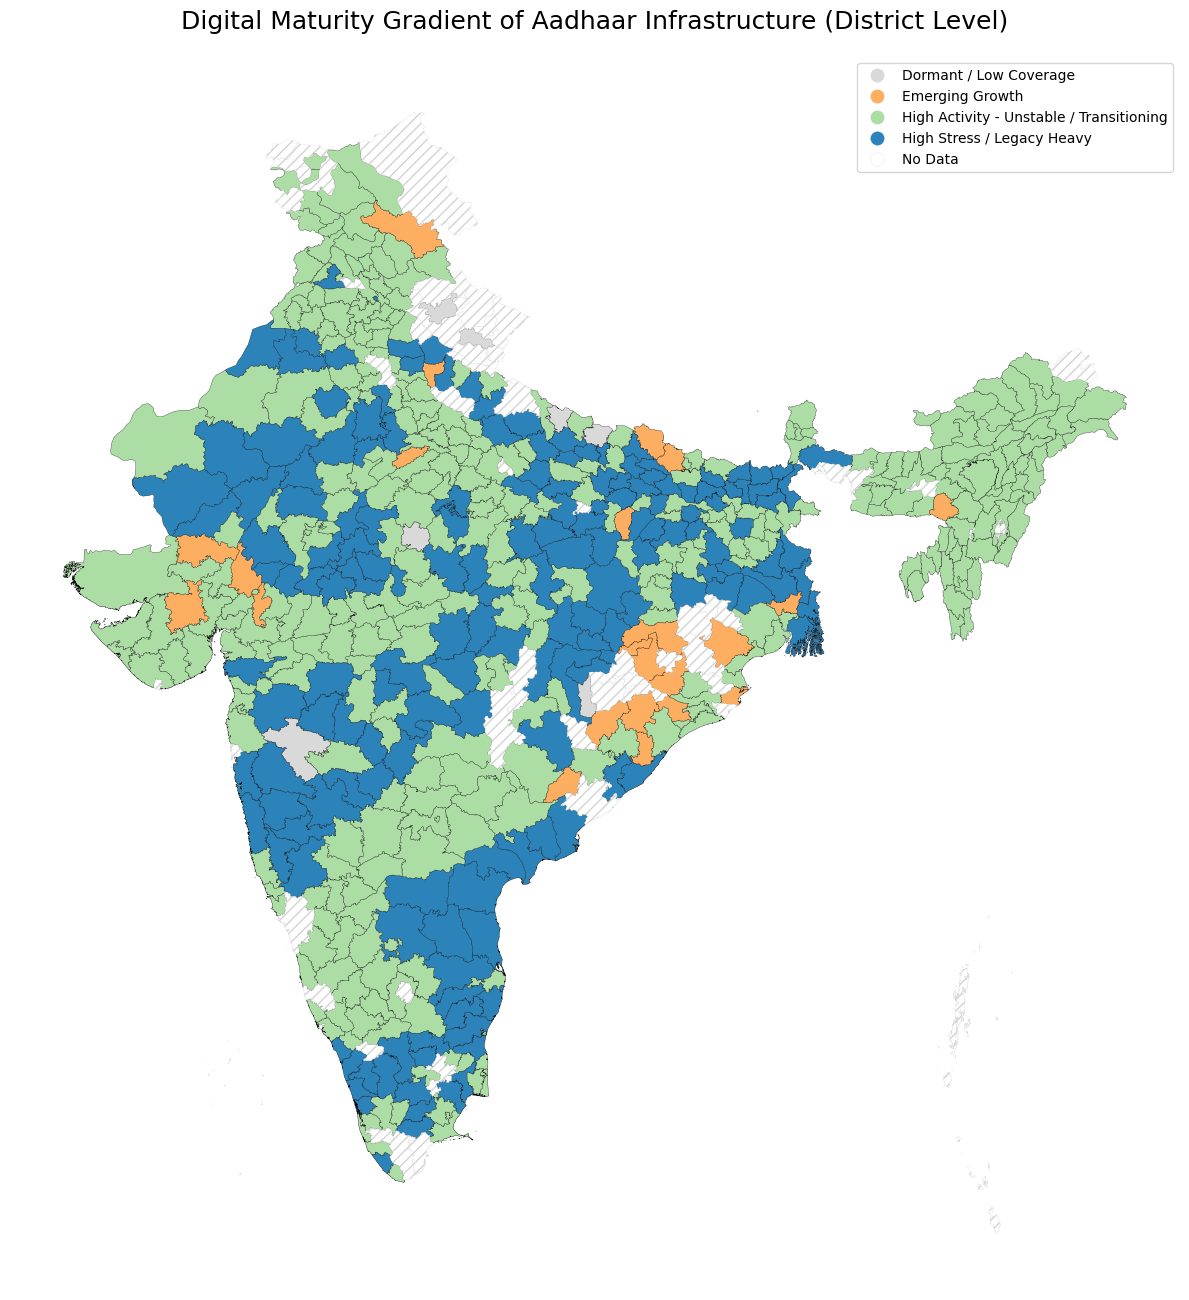

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(12, 14))

map_df.plot(
    column="maturity_label",
    categorical=True,
    legend=True,
    cmap=maturity_cmap,
    linewidth=0.2,
    edgecolor="black",
    ax=ax,
    missing_kwds={
        "color": "white",
        "edgecolor": "lightgrey",
        "hatch": "///",
        "label": "No Data"
    }
)

ax.set_title(
    "Digital Maturity Gradient of Aadhaar Infrastructure (District Level)",
    fontsize=18,
    pad=20
)

ax.axis("off")

plt.tight_layout()
plt.show()


### Digital Maturity x Mean Monthly Activity Map

In [28]:
map_df = map_df.merge(
    digital_maturity_df[
        ["state", "district", "mean_monthly_activity"]
    ],
    on=["state", "district"],
    how="left"
)


In [29]:
import numpy as np

# Replace NaN with 0 for plotting
map_df["mean_monthly_activity"] = map_df["mean_monthly_activity"].fillna(0)

# Create a scaled size for plotting
map_df["activity_size"] = np.sqrt(map_df["mean_monthly_activity"])


In [30]:
activity_quantiles = map_df["mean_monthly_activity"].quantile([0.25, 0.5, 0.75]).round(0)
activity_quantiles


0.25     1983.0
0.50    12173.0
0.75    22948.0
Name: mean_monthly_activity, dtype: float64

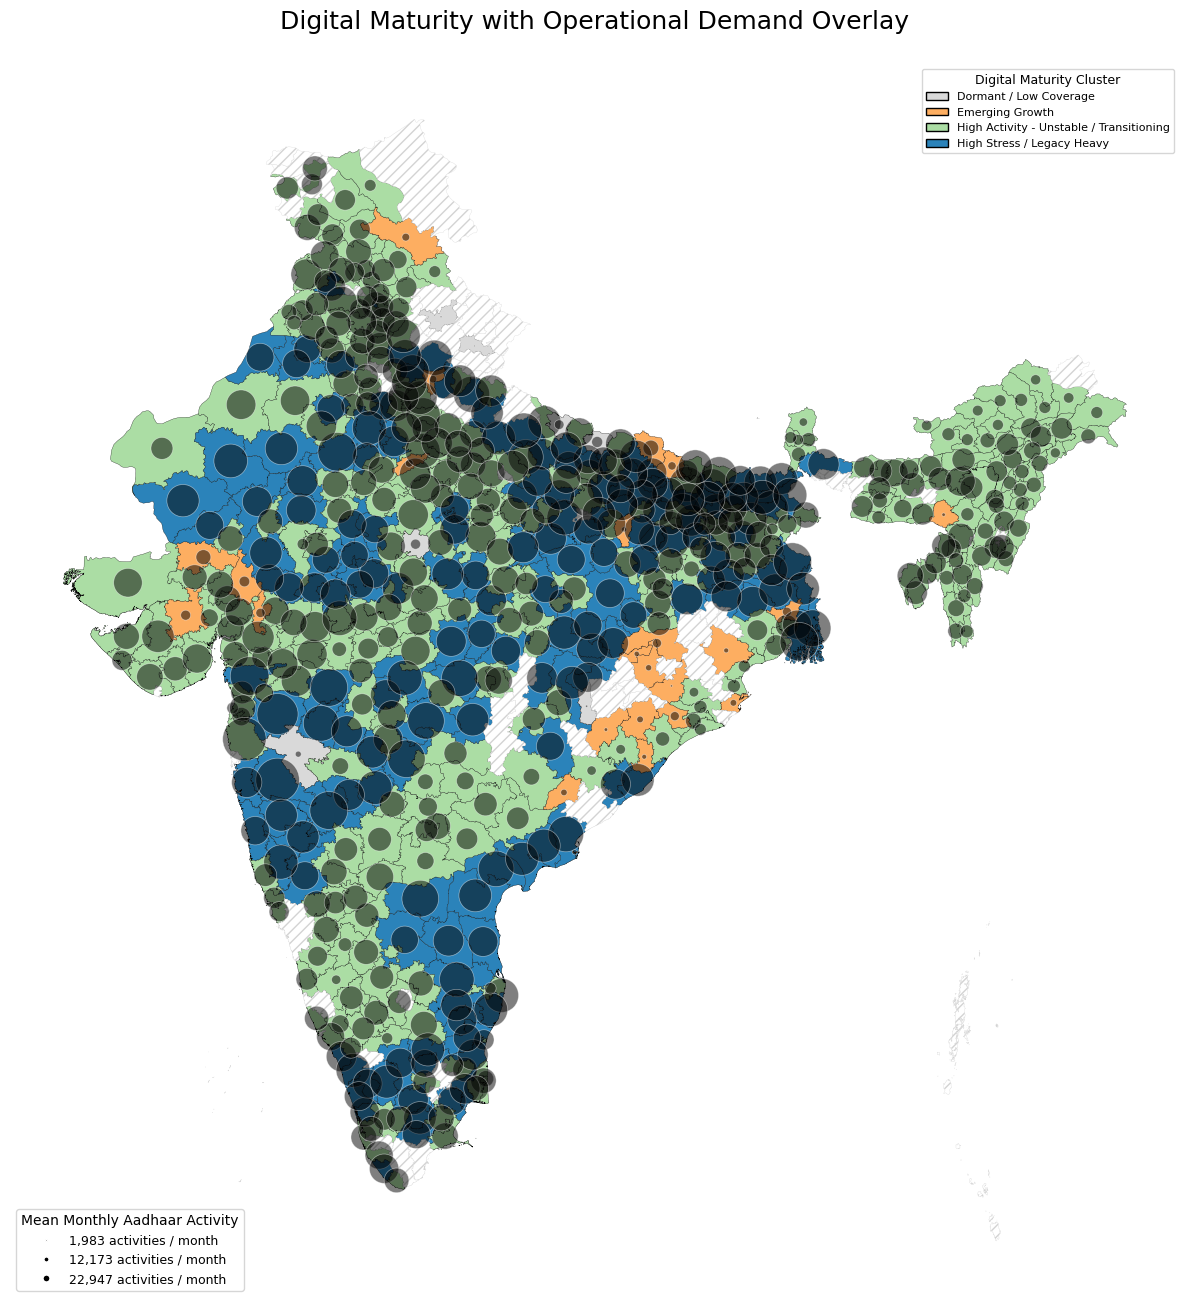

In [31]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

fig, ax = plt.subplots(1, 1, figsize=(12, 14))

# Base maturity map
map_df.plot(
    column="maturity_label",
    categorical=True,
    categories=maturity_order,
    cmap=maturity_cmap,
    linewidth=0.2,
    edgecolor="black",
    ax=ax,
    legend=False,
    missing_kwds={
        "color": "white",
        "edgecolor": "lightgrey",
        "hatch": "///",
        "label": "No Data"
    }
)

# Overlay activity circles at district centroids
activity_df = map_df[map_df["mean_monthly_activity"] > 0].copy()

# Project to a suitable CRS for India (Asia South Albers Equal Area Conic)
activity_df_projected = activity_df.to_crs("EPSG:24378")
activity_df["centroid"] = activity_df_projected.geometry.centroid.to_crs(map_df.crs)

ax.scatter(
    x=activity_df["centroid"].x,
    y=activity_df["centroid"].y,
    s=activity_df["activity_size"] * 3,  # Scale factor for visibility
    color="black",
    alpha=0.5,
    linewidth=0.5,
    edgecolor="white"
)

# Title + subtitle
ax.set_title(
    "Digital Maturity with Operational Demand Overlay",
    fontsize=18,
    pad=25
)

# Create size legend with reasonable marker sizes
activity_quantiles = map_df["mean_monthly_activity"].quantile([0.25, 0.5, 0.75])

legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        label=f"{int(val):,} activities / month",
        markerfacecolor="black",
        markeredgecolor="white",
        markersize=np.sqrt(val) / 30  # Scale down for legend
    )
    for val in activity_quantiles
]

size_legend = ax.legend(
    handles=legend_handles,
    title="Mean Monthly Aadhaar Activity",
    loc="lower left",
    frameon=True,
    fontsize=9
)

# Add maturity color legend
maturity_legend_handles = [
    Patch(facecolor=maturity_colors[label], edgecolor='black', label=label)
    for label in maturity_order
]

ax.legend(
    handles=maturity_legend_handles,
    title="Digital Maturity Cluster",
    loc="upper right",
    frameon=True,
    fontsize=8,
    title_fontsize=9
)

# Add back the size legend
ax.add_artist(size_legend)

ax.axis("off")
plt.tight_layout()
plt.show()


### Expansion vs Correction Scatter

In [32]:
scatter_df = digital_maturity_df[
    ["mean_monthly_activity", "mean_update_to_enrolment_ratio", "maturity_label", "district"]
].dropna()

In [33]:
cluster_colors = {
    "Dormant / Low Coverage": "#d9d9d9",
    "Emerging Growth": "#fdae61",
    "High Activity - Unstable / Transitioning": "#abdda4",
    "High Stress / Legacy Heavy": "#2b83ba"
}


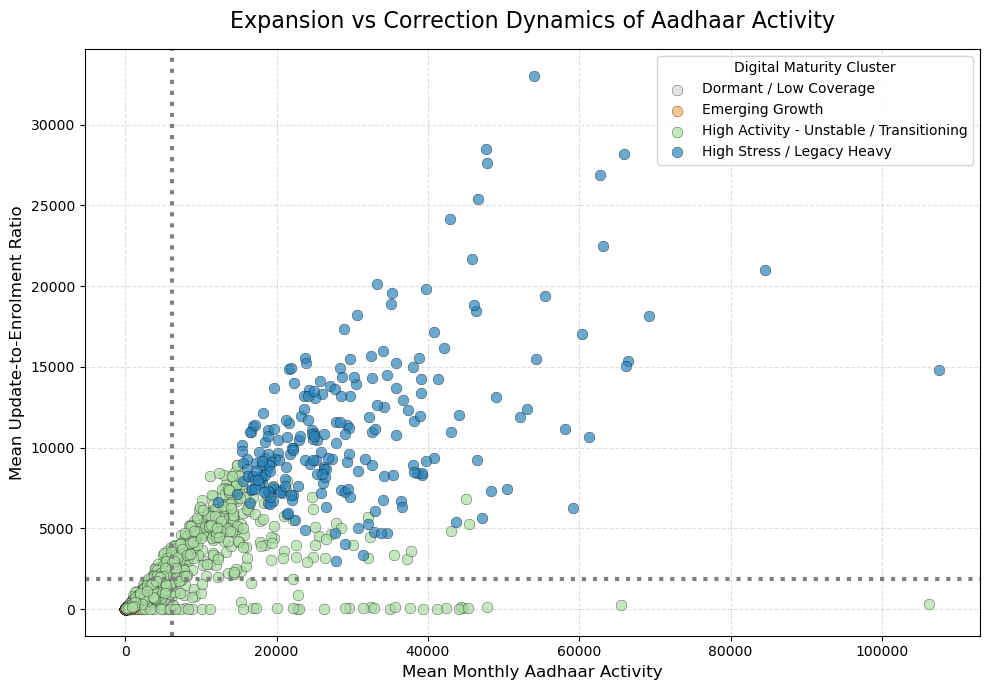

In [34]:
fig, ax = plt.subplots(figsize=(10, 7))

for cluster, color in cluster_colors.items():
    subset = scatter_df[scatter_df["maturity_label"] == cluster]
    
    ax.scatter(
        subset["mean_monthly_activity"],
        subset["mean_update_to_enrolment_ratio"],
        label=cluster,
        color=color,
        alpha=0.7,
        edgecolor="black",
        linewidth=0.3,
        s=60
    )

ax.set_title(
    "Expansion vs Correction Dynamics of Aadhaar Activity",
    fontsize=16,
    pad=15
)

ax.set_xlabel("Mean Monthly Aadhaar Activity", fontsize=12)
ax.set_ylabel("Mean Update-to-Enrolment Ratio", fontsize=12)

ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(title="Digital Maturity Cluster", frameon=True)

ax.axvline(
    scatter_df["mean_monthly_activity"].median(),
    color="grey",
    linestyle=":",
    linewidth=3
)

ax.axhline(
    scatter_df["mean_update_to_enrolment_ratio"].median(),
    color="grey",
    linestyle=":",
    linewidth=3
)


plt.tight_layout()
plt.show()

### Dormancy Heatmap (District × Month)

In [35]:
monthly_base = pd.read_csv("data/monthly_metrics.csv")

In [36]:
dormancy_index = (
    monthly_base
    .groupby(["state", "district"], as_index=False)
    .agg(
        dormancy_index=("is_active", lambda x: 1 - x.mean())
    )
)

In [37]:
top_dormant = (
    dormancy_index
    .sort_values("dormancy_index", ascending=False)
    .head(30)
    [["state", "district"]]
)


In [38]:
heatmap_df = (
    monthly_base
    .merge(top_dormant, on=["state", "district"], how="inner")
    .pivot_table(
        index="district",
        columns="month",
        values="is_active",
        fill_value=0
    )
)


In [39]:
heatmap_df = heatmap_df.sort_index(axis=1)

/tmp/ipykernel_8804/729309541.py:36: UserWarning: Glyph 136 (\x88) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8804/729309541.py:36: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dhiran/miniconda3/envs/ml_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 136 (\x88) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dhiran/miniconda3/envs/ml_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


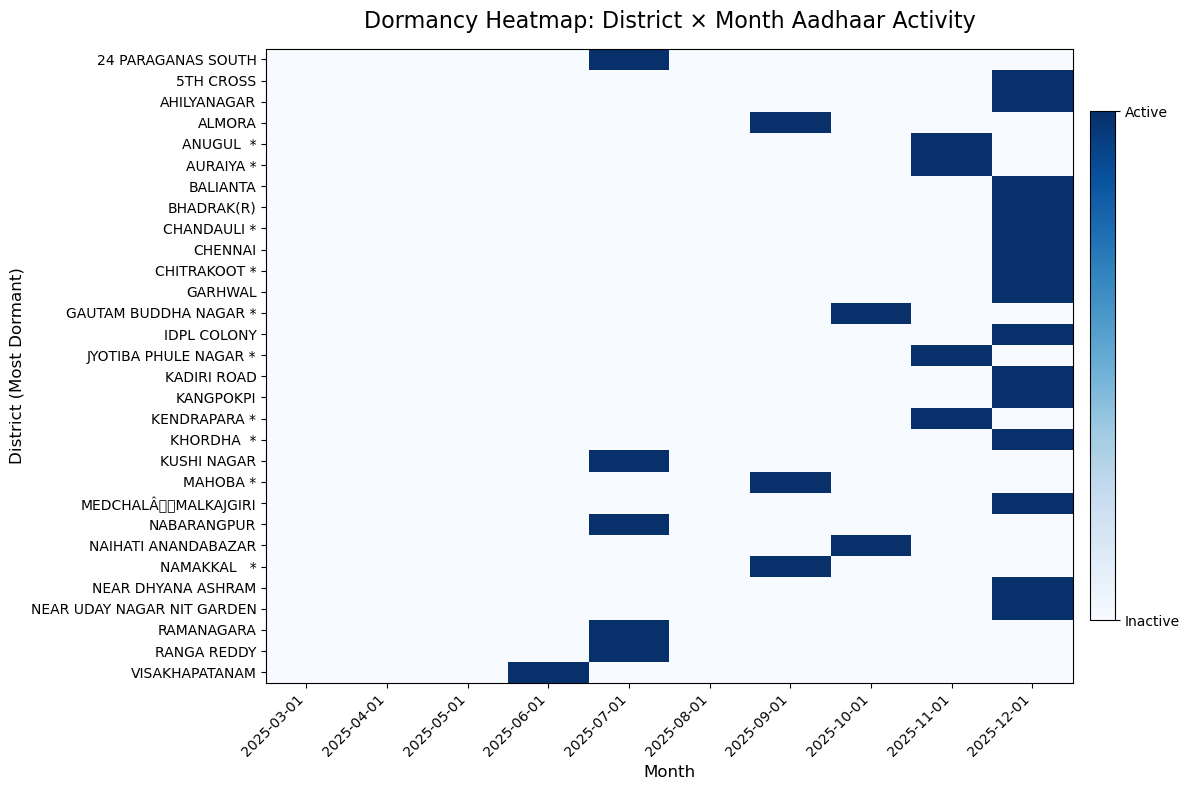

In [40]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))

im = ax.imshow(
    heatmap_df.values,
    aspect="auto",
    cmap="Blues",
    interpolation="nearest"
)

ax.set_title(
    "Dormancy Heatmap: District × Month Aadhaar Activity",
    fontsize=16,
    pad=15
)

ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("District (Most Dormant)", fontsize=12)

ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(
    heatmap_df.columns.astype(str),
    rotation=45,
    ha="right"
)

ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

# Binary colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["Inactive", "Active"])

plt.tight_layout()
plt.show()


### BDS / CCI Ranking Table (Targeted Policy Flags)

In [41]:
bds_summary = pd.read_csv("data/district_summary/district_bds_summary.csv")
cci_summary = pd.read_csv("data/district_summary/district_cci_summary.csv")

In [42]:
top_bds = (
    bds_summary
    .sort_values("mean_bds", ascending=False)
    .head(10)
)

bottom_cci = (
    cci_summary
    .sort_values("mean_cci", ascending=True)
    .head(10)
)


In [43]:
cluster_info = digital_maturity_df[
    ["state", "district", "maturity_label"]
]

top_bds = top_bds.merge(
    cluster_info, on=["state", "district"], how="left"
)

bottom_cci = bottom_cci.merge(
    cluster_info, on=["state", "district"], how="left"
)


In [44]:
top_bds_display = top_bds[[
    "state", "district", "mean_bds", "maturity_label"
]].rename(columns={
    "mean_bds": "Mean Biometric Decay Score (BDS)"
})

top_bds_display["Mean Biometric Decay Score (BDS)"] = (
    top_bds_display["Mean Biometric Decay Score (BDS)"].round(2)
)


In [45]:
bottom_cci_display = bottom_cci[[
    "state", "district", "mean_cci", "maturity_label"
]].rename(columns={
    "mean_cci": "Mean Child Compliance Index (CCI)"
})

bottom_cci_display["Mean Child Compliance Index (CCI)"] = (
    bottom_cci_display["Mean Child Compliance Index (CCI)"].round(2)
)


In [46]:
from IPython.display import display

print("Top 10 Districts by Adult Biometric Decay (BDS)")
display(top_bds_display.reset_index(drop=True))

print("\nBottom 10 Districts by Child Compliance Index (CCI)")
display(bottom_cci_display.reset_index(drop=True))


Top 10 Districts by Adult Biometric Decay (BDS)


,state,district,Mean Biometric Decay Score (BDS),maturity_label
0,CHHATTISGARH,DANTEWADA,0.77,High Activity - Unstable / Transitioning
1,PONDICHERRY,PONDICHERRY,0.75,High Activity - Unstable / Transitioning
2,MADHYA PRADESH,HOSHANGABAD,0.74,High Activity - Unstable / Transitioning
3,MADHYA PRADESH,WEST NIMAR,0.74,High Activity - Unstable / Transitioning
4,ORISSA,KHORDHA,0.74,High Activity - Unstable / Transitioning
5,NAGALAND,PHEK,0.73,High Activity - Unstable / Transitioning
6,MADHYA PRADESH,HARDA *,0.73,High Activity - Unstable / Transitioning
7,MAHARASHTRA,WARDHA,0.72,High Activity - Unstable / Transitioning
8,CHHATTISGARH,DAKSHIN BASTAR DANTEWADA,0.72,High Activity - Unstable / Transitioning
9,ORISSA,CUTTACK,0.72,High Activity - Unstable / Transitioning



Bottom 10 Districts by Child Compliance Index (CCI)


,state,district,Mean Child Compliance Index (CCI),maturity_label
0,WESTBENGAL,HOWRAH,0.0,Emerging Growth
1,WEST BENGAL,SOUTH TWENTY FOUR PARGANAS,0.0,Emerging Growth
2,WEST BENGAL,MEDINIPUR WEST,0.0,Dormant / Low Coverage
3,WEST BENGAL,NAIHATI ANANDABAZAR,0.0,Dormant / Low Coverage
4,WEST BENGLI,HOOGHLY,0.0,Dormant / Low Coverage
5,ANDHRA PRADESH,SPSR NELLORE,0.0,Dormant / Low Coverage
6,ORISSA,KENDRAPARA *,0.0,Dormant / Low Coverage
7,ORISSA,JAJAPUR *,0.0,Dormant / Low Coverage
8,BALANAGAR,IDPL COLONY,0.0,Dormant / Low Coverage
9,UTTARANCHAL,ALMORA,0.0,Dormant / Low Coverage
